## **Atividade 7:  TF-IDF e Word2Vec**

Vitor Hugo da Silva Santos

RA: 625102765

In [1]:
# =======================================================================
# CÉLULA 1: SETUP E TREINAMENTO (Execute apenas uma vez)
# =======================================================================

# 1. Instalação e Importação de Bibliotecas
print("Instalando e carregando bibliotecas...")
!pip install nltk scikit-learn pandas matplotlib -q
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# 2. Baixar recursos do NLTK
print("Baixando pacotes NLTK...")
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# 3. Criar dataset fictício
data = {
    'title': [
        'The Godfather', 'The Shawshank Redemption', 'Schindlers List', 'Raging Bull',
        'Casablanca', 'One Flew Over the Cuckoos Nest', 'Gone with the Wind',
        'Citizen Kane', 'The Wizard of Oz', 'Titanic', 'Lawrence of Arabia',
        'Psycho', 'Sunset Blvd.', 'Vertigo'
    ],
    'description': [
        'A mafia don transfers control of his empire to his reluctant son, leading to family conflicts and betrayals in the criminal underworld.',
        'A banker is convicted of murder and sent to prison, where he befriends a fellow inmate and finds hope through redemption.',
        'A businessman saves Jewish workers during the Holocaust by employing them in his factory, risking his life.',
        'A boxer rises to fame but struggles with jealousy, violence, and personal demons in his relationships.',
        'During WWII, refugees and spies converge in Casablanca, where a cynical American helps a resistance leader escape.',
        'A man fakes insanity to avoid prison labor, but clashes with a tyrannical nurse in a mental institution.',
        'A Southern belle navigates love, war, and survival during the American Civil War and Reconstruction.',
        'A newspaper magnate builds an empire but faces personal losses, with his last word revealing a mystery.',
        'A girl is swept away to Oz, embarking on a quest to return home while facing witches and companions.',
        'A love story unfolds on the Titanic, where a wealthy woman falls for a poor artist amidst the ships sinking.',
        'A British officer leads Arab tribes against the Turks in WWI, grappling with leadership and identity.',
        'A secretary steals money and flees, leading to a terrifying encounter at a remote motel.',
        'A faded star hires a writer, leading to obsession, delusion, and tragedy in Hollywood.',
        'A detective with vertigo investigates a womans mysterious behavior, uncovering deception and tragedy.'
    ]
}
df = pd.DataFrame(data)
print("Dataset de filmes carregado.")

# 4. Função de pré-processamento
def preprocess_text(text):
    text = re.sub(r'[^\w\s]', '', text.lower())
    tokens = nltk.word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

# Aplicar pré-processamento
df['processed_description'] = df['description'].apply(preprocess_text)

# 5. Aplicar TF-IDF
print("Treinando o modelo TF-IDF...")
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['processed_description'])
print("Modelo TF-IDF treinado com sucesso.")

# 6. Função para encontrar filmes similares
def find_similar_movies(query_description, top_n=3):
    processed_query = preprocess_text(query_description)
    query_vector = vectorizer.transform([processed_query])
    similarities = cosine_similarity(query_vector, tfidf_matrix).flatten()
    top_indices = similarities.argsort()[-top_n:][::-1]
    results = [(df.iloc[i]['title'], similarities[i]) for i in top_indices]
    return results

print("\n>>> SETUP CONCLUÍDO. <<<")
print("Execute a próxima célula para fazer sua consulta.")

Instalando e carregando bibliotecas...
Baixando pacotes NLTK...
Dataset de filmes carregado.
Treinando o modelo TF-IDF...
Modelo TF-IDF treinado com sucesso.

>>> SETUP CONCLUÍDO. <<<
Execute a próxima célula para fazer sua consulta.



Escolha uma descrição de filme digitando o número correspondente:
1. A mafia don transfers control of his empire to his reluctant son, leading to family conflicts and betrayals in the criminal underworld.
2. A banker is convicted of murder and sent to prison, where he befriends a fellow inmate and finds hope through redemption.
3. A businessman saves Jewish workers during the Holocaust by employing them in his factory, risking his life.
4. A boxer rises to fame but struggles with jealousy, violence, and personal demons in his relationships.
5. During WWII, refugees and spies converge in Casablanca, where a cynical American helps a resistance leader escape.
6. A man fakes insanity to avoid prison labor, but clashes with a tyrannical nurse in a mental institution.
7. A Southern belle navigates love, war, and survival during the American Civil War and Reconstruction.
8. A newspaper magnate builds an empire but faces personal losses, with his last word revealing a mystery.
9. A girl is sw

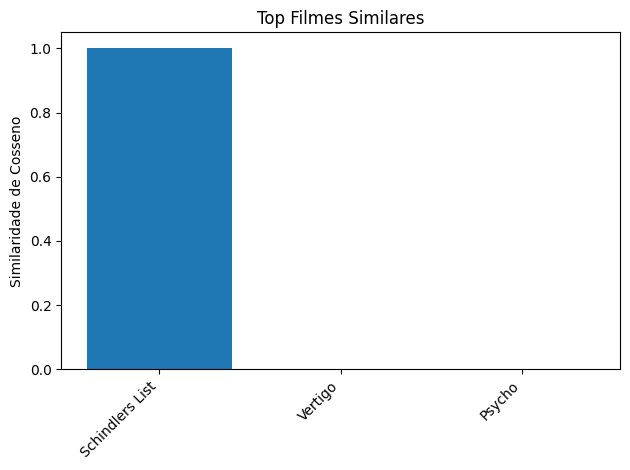


--- Fim da análise ---
Para fazer uma nova consulta, apenas execute esta célula novamente.


In [2]:
# =======================================================================
# CÉLULA 2: FAZER UMA NOVA RECOMENDAÇÃO (Execute esta célula)
# =======================================================================

# 1. Listar descrições para o usuário
print("\nEscolha uma descrição de filme digitando o número correspondente:")
for i, desc in enumerate(df['description'], start=1):
    print(f"{i}. {desc}")

# 2. Receber a escolha do usuário
try:
    choice = int(input("\nDigite o número da descrição escolhida: "))

    if 1 <= choice <= len(df):
        selected_description = df.iloc[choice - 1]['description']
        print(f"\nVocê escolheu: {selected_description}")

        # 3. Encontrar filmes similares (chama a função da Célula 1)
        similar_movies = find_similar_movies(selected_description)

        # 4. Exibir resultados em texto
        print("\nFilmes similares à descrição escolhida:")
        for title, score in similar_movies:
            print(f"- {title}: Similaridade {score:.2f}")

        # 5. Visualização
        print("\nGerando gráfico...")
        plt.figure()
        plt.bar([title for title, _ in similar_movies], [score for _, score in similar_movies])
        plt.title("Top Filmes Similares")
        plt.ylabel("Similaridade de Cosseno")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show() # Exibe o gráfico

        print("\n--- Fim da análise ---")
        print("Para fazer uma nova consulta, apenas execute esta célula novamente.")

    else:
        print(f"Número inválido. Escolha um número entre 1 e {len(df)}")

except ValueError:
    print("Entrada inválida. Por favor, digite um número inteiro.")
except Exception as e:
    print(f"Ocorreu um erro inesperado: {e}")